# **Importing Necessary Library**

In [1]:
import os
import random
import pathlib
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn import metrics
from tensorflow import keras
from tensorflow.keras import Model, Input
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import Rescaling, Conv2D, MaxPooling2D, BatchNormalization,Flatten, Dense, Dropout, Flatten

# **Checking GPU Avaibility**

In [2]:
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    print('GPU is available')
else:
    print('No GPU detected')

num_gpus = len(physical_devices)

if num_gpus > 0:
    print(f"Number of available GPUs: {num_gpus}")
    for i in range(num_gpus):
        print(f"GPU {i}: {tf.config.experimental.get_device_details(physical_devices[0])}")
else:
    print("No GPUs available")

device = tf.device('gpu:0' if len(physical_devices) > 0 else 'cpu:0')

GPU is available
Number of available GPUs: 1
GPU 0: {'device_name': 'NVIDIA GeForce RTX 3060', 'compute_capability': (8, 6)}


# **Dataset Path**

In [3]:
data_dir = 'D:\Accelx\Dataset'
os.listdir(data_dir)

['Cat', 'Dog']

In [4]:
# Set the path to the dataset
dataset_path = data_dir

# Initialize empty lists for storing the images and labels
images = []
labels = []

# Loop over the subfolders in the dataset
for subfolder in os.listdir(dataset_path):
    
    subfolder_path = os.path.join(dataset_path, subfolder)
    if not os.path.isdir(subfolder_path):
        continue
  
  # Loop over the images in the subfolder
    for image_filename in os.listdir(subfolder_path):
       # Load the image and store it in the images list
        image_path = os.path.join(subfolder_path, image_filename)
        images.append(image_path)
    
        # Store the label for the image in the labels list
        labels.append(subfolder)
 
 # Create a pandas DataFrame from the images and labels
df = pd.DataFrame({'image': images, 'label': labels})

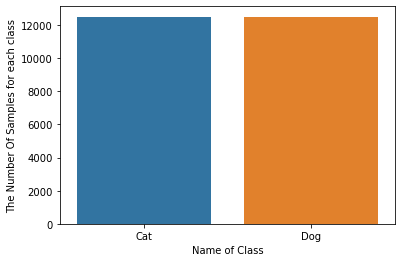

In [5]:
# plot the classes
ax = sns.countplot(x=df.label)

# Set labels and titles
ax.set_xlabel("Name of Class")
ax.set_ylabel("The Number Of Samples for each class")

# Rotate x-axis labels if needed
plt.xticks()

# plt.savefig('D:\Brain MRI Dataset\Bar Plot.pdf', bbox_inches='tight')

# Display the plot
plt.show()

# **Data Preprocessing**

Dividing the dataset into train, validation, test in 80:10:10 ratio

In [6]:
tf.random.set_seed(42)

train_data = keras.utils.image_dataset_from_directory(data_dir, validation_split = 0.1, subset = 'training', seed = 1, shuffle = True, batch_size = 32, image_size=(128,128))

test_data = keras.utils.image_dataset_from_directory(data_dir, validation_split = 0.1, subset = 'validation', seed = 1, shuffle = True, batch_size = 32, image_size=(128,128))

Found 24993 files belonging to 2 classes.
Using 22494 files for training.
Found 24993 files belonging to 2 classes.
Using 2499 files for validation.


In [7]:
filenames = pathlib.Path(data_dir)
for label in train_data.class_names :
    images = list(filenames.glob(f'{label}/*'))
    print(f'{label} : {len(images)}')

Cat : 12495
Dog : 12498


In [8]:
train_data.cardinality().numpy(),  test_data.cardinality().numpy()

(703, 79)

In [9]:
train_set = train_data.take(624)
val_set = train_data.skip(624)

In [10]:
train_set.cardinality().numpy(), val_set.cardinality().numpy()

(624, 79)

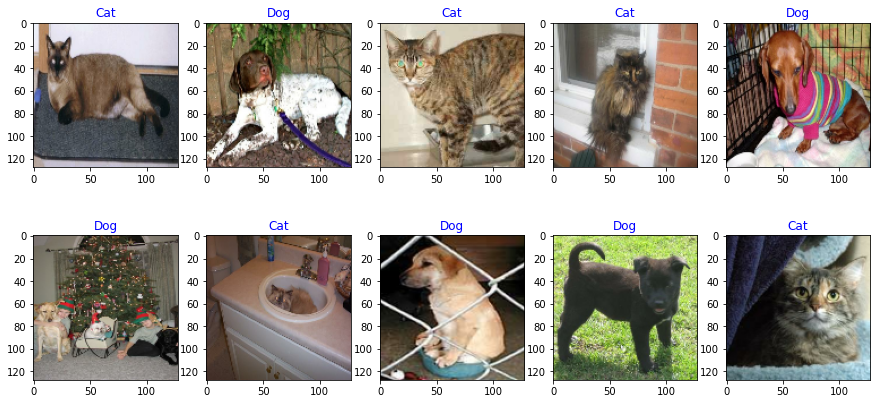

In [11]:
# print random images from the train set
plt.figure(figsize = (15, 15))
for images, labels in train_set.take(1):
    for i in range(10):
        index = random.randint(0, len(images))
        ax = plt.subplot(4, 5, i + 1)
        plt.imshow(images[index].numpy().astype("uint8"))
        plt.title(train_data.class_names[labels[index]], color= 'blue', fontsize= 12)
        plt.axis(True)

plt.show()

In [12]:
for images_batch, labels_batch in train_set:
    print(images_batch.shape)
    print(labels_batch.shape)
    break

(32, 128, 128, 3)
(32,)


# **Custom CNN Model Implementation**

In [14]:
tf.random.set_seed(42)

# Define the input layer
input_layer = Input(shape=(128, 128, 3))

# Normalize pixel values
x = Rescaling(1./255)(input_layer)

# First convolutional block
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.15)(x)

# Second convolutional block
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.15)(x)

# Third convolutional block
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.15)(x)

# Fourth convolutional block
x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.3)(x)

# Global pooling and dense layers
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Output layer
output_layer = Dense(2, activation='softmax')(x)

In [15]:
# Create the model
model = Model(inputs=input_layer, outputs=output_layer)

In [16]:
# Print the model summary
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 128, 128, 3)]     0         
_________________________________________________________________
rescaling (Rescaling)        (None, 128, 128, 3)       0         
_________________________________________________________________
conv2d (Conv2D)              (None, 128, 128, 32)      896       
_________________________________________________________________
batch_normalization (BatchNo (None, 128, 128, 32)      128       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 128, 128, 32)      9248      
_________________________________________________________________
batch_normalization_1 (Batch (None, 128, 128, 32)      128       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 64, 64, 32)        0     

The model was trained using the Adam optimizer with an initial learning rate of 0.001. A dynamic learning rate scheduler (ReduceLROnPlateau) was applied, reducing the rate by a factor of 0.5 upon stagnation of validation accuracy for 2 epochs, with a lower bound of 1e-5.

This is a solution to optimize convergence and avoid some overfitting while dynamically adjusting learning rate.

In [17]:
learning_rate_reduction = ReduceLROnPlateau(monitor = 'val_accuracy',
                                            patience=2,
                                            factor=0.5,
                                            min_lr = 0.00001,
                                            verbose = 1)

In [18]:
model.compile(loss = keras.losses.SparseCategoricalCrossentropy(), optimizer = keras.optimizers.Adam(), metrics = 'accuracy')

In [19]:
history_1 = model.fit(train_set, callbacks=[learning_rate_reduction], epochs=30, validation_data=val_set)

Epoch 1/30
624/624 [==============================] - 59s 86ms/step - loss: 0.6713 - accuracy: 0.6618 - val_loss: 0.5164 - val_accuracy: 0.7419
Epoch 2/30
624/624 [==============================] - 32s 52ms/step - loss: 0.4700 - accuracy: 0.7759 - val_loss: 0.4206 - val_accuracy: 0.7981
Epoch 3/30
624/624 [==============================] - 32s 52ms/step - loss: 0.3639 - accuracy: 0.8383 - val_loss: 0.3011 - val_accuracy: 0.8765
Epoch 4/30
624/624 [==============================] - 32s 52ms/step - loss: 0.2985 - accuracy: 0.8725 - val_loss: 0.2536 - val_accuracy: 0.8967
Epoch 5/30
624/624 [==============================] - 32s 52ms/step - loss: 0.2257 - accuracy: 0.9068 - val_loss: 0.2968 - val_accuracy: 0.8674
Epoch 6/30
624/624 [==============================] - 32s 52ms/step - loss: 0.1939 - accuracy: 0.9193 - val_loss: 0.2284 - val_accuracy: 0.9074
Epoch 7/30
624/624 [==============================] - 33s 53ms/step - loss: 0.1703 - accuracy: 0.9314 - val_loss: 0.2242 - val_accuracy:

# **Saving Model**

In [20]:
# Save the model
model.save('D:\Accelx\Model\cnnModel.h5')

# **Loading Model**

In [21]:
model = load_model('D:\Accelx\Model\cnnModel.h5')

# **Training Performance Visualization**

Based on the Training and Validation Loss and Accuracy Curves, this model is likely have some overfitting issues. Because,
* There is a clear gap between training and validation performance (both in accuracy and loss).
* Training performance keeps improving while validation stops improving after a certain point.

Proposed Solutions to Reduce Overfitting:
* Hyperparameter Tuning
* Modification of the CNN Architecture
* Early Stopping, to stop training by monitoring validation Loss and when it stops improving to prevent over-training
* Data Augmentation Techniques
* K-fold cross-validation to ensure model is not overfitting to a specific split

In [22]:
def plot_training_curves(history_df):
    plt.figure(figsize = (13, 4), dpi = 120)
    ax = plt.subplot(1, 2, 1)
    plt.plot(range(1, len(history_df) + 1), history_df['loss'], label = 'Training Loss')
    plt.plot(range(1, len(history_df) + 1), history_df['val_loss'], label = 'Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Cross Entropy')
    plt.grid()
    plt.legend()
    ax = plt.subplot(1, 2, 2) 
    plt.plot(range(1, len(history_df) + 1), history_df['accuracy'], label = 'Training Accuracy')
    plt.plot(range(1, len(history_df) + 1), history_df['val_accuracy'], label = 'Validation Accurcay')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid()
    plt.legend()
    plt.show()

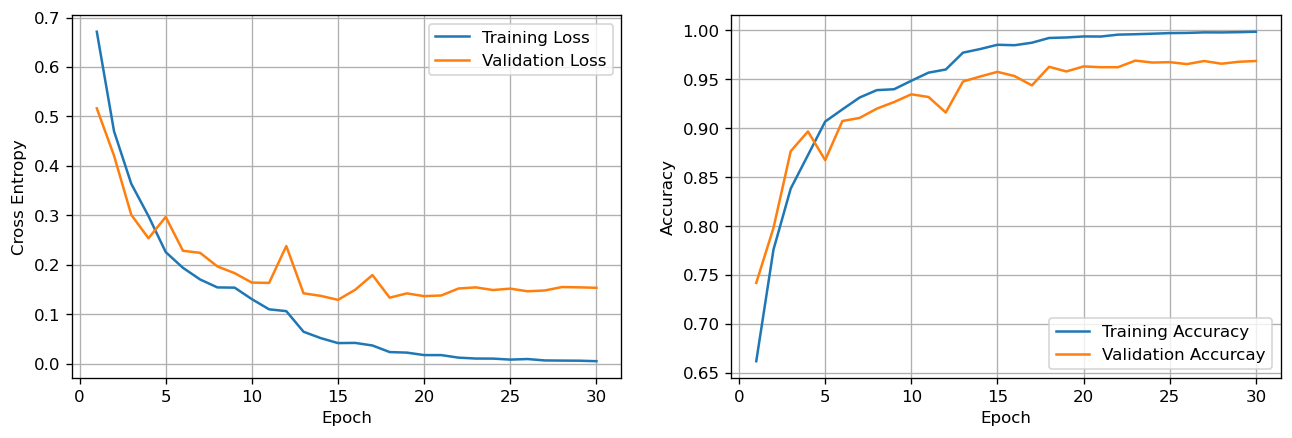

In [23]:
plot_training_curves(pd.DataFrame(history_1.history))

# **Model Evaluation**

In [24]:
X_test, y_test = None, None
for images, labels in test_data:
    if X_test == None or y_test == None:
        X_test = images
        y_test = labels
    else:
        X_test = tf.concat([X_test, images], axis = 0)
        y_test = tf.concat([y_test, labels], axis = 0)
        
X_test.shape, y_test.shape

(TensorShape([2499, 128, 128, 3]), TensorShape([2499]))

In [25]:
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis = 1)

In [26]:
test_score = model.evaluate(test_data, verbose= 1)

print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

79/79 [==============================] - 1s 16ms/step - loss: 0.1959 - accuracy: 0.9572
Test Loss:  0.1959351748228073
Test Accuracy:  0.9571828842163086


# **Classification Report**

In [27]:
target_names = ['Cat', 'Dog']
print(classification_report(y_test , y_pred, target_names=target_names, digits=5))

              precision    recall  f1-score   support

         Cat    0.96016   0.95642   0.95828      1285
         Dog    0.95406   0.95799   0.95602      1214

    accuracy                        0.95718      2499
   macro avg    0.95711   0.95721   0.95715      2499
weighted avg    0.95720   0.95718   0.95719      2499



# **Confusion Matrix**

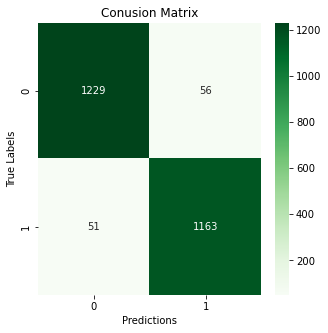

In [28]:
plt.figure(figsize = (5,5))
sns.heatmap(metrics.confusion_matrix(y_test, y_pred), annot = True, fmt='d', cmap = 'Greens')
plt.xlabel('Predictions')
plt.ylabel('True Labels')
plt.title('Conusion Matrix')
plt.show()

# **Predicting Some Random Sample Images**

In [29]:
# plot random images from a given dataset, and compare predictions with ground truth
def plot_random_predictions(dataset, model):

    shuffled_data = dataset.shuffle(10)
    class_names = dataset.class_names

    for images, labels in shuffled_data.take(1):
        plt.figure(figsize = (10, 10), dpi = 120)
        y_pred_proba = model.predict(images)

    for i in range(9):
        index = random.randint(0, len(images))
        ax = plt.subplot(3,3, i + 1)

        img = images[index].numpy().astype("uint8")
        y_true = class_names[labels[index]]
        y_pred = class_names[np.argmax(y_pred_proba[index], axis = 0)]
      
        c = 'g' if y_pred == y_true else 'r'
      
        plt.imshow(img)
        plt.title(f'Predicted : {y_pred}\nTrue label : {y_true}', c = c)
        plt.axis(False)

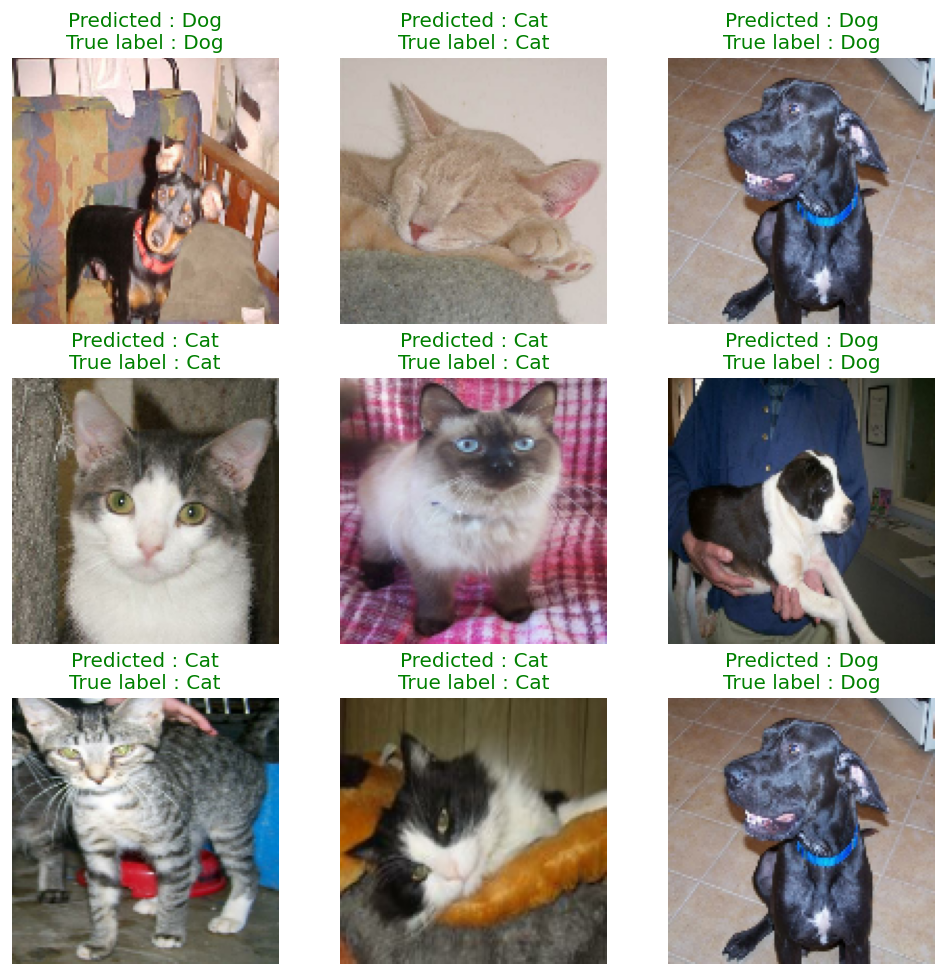

In [30]:
plot_random_predictions(test_data, model)